# Contexte du Projet : Comparaison des MLP et CNN pour la Classification d'Images

Ce rapport détaille une exploration et une comparaison des performances des réseaux de neurones multi-couches (MLP) et des réseaux de neurones convolutifs (CNN) pour la tâche de classification d'images, en utilisant le jeu de données Fashion-MNIST. L'objectif principal est de démontrer l'efficacité supérieure des CNN dans le traitement des données visuelles et d'analyser l'impact de diverses décisions architecturales sur leurs performances.

## Démarche et Méthodologie

Le projet a été structuré en plusieurs phases clés :

1.  **Initialisation et Préparation :** Nous avons commencé par configurer l'environnement de développement (Google Colab), importer les bibliothèques nécessaires (`torch`, `torchvision`, `numpy`, `matplotlib`, `seaborn`, `pandas`, `sklearn`) et fixer les graines pour assurer la reproductibilité des expériences.

2.  **Implémentations Manuelles :** Pour approfondir la compréhension des mécanismes fondamentaux des CNN, nous avons implémenté manuellement les opérations de convolution 2D (`corr2d`) et de pooling 2D (`pool2d`).

3.  **Chargement et Exploration des Données :** Le jeu de données Fashion-MNIST a été chargé, normalisé et divisé en ensembles d'entraînement, de validation et de test. Une visualisation des échantillons a été effectuée pour comprendre la nature des données.

4.  **Définition des Utilitaires d'Entraînement :** Une fonction `train_model` générique a été développée pour l'entraînement des modèles, intégrant la validation et un mécanisme d'arrêt anticipé (`early stopping`).

5.  **Modèle Baseline MLP :** Un MLP simple a été conçu, entraîné et évalué pour établir une performance de référence. Ce modèle traite les images comme des vecteurs plats, ignorant leur structure spatiale.

6.  **Modèle CNN (LeNet) :** Une architecture CNN inspirée de LeNet-5 a été implémentée, entraînée et évaluée. Ce modèle exploite les convolutions et le pooling pour capturer les caractéristiques hiérarchiques des images.

7.  **Expériences Architecturales :** Plusieurs variantes de l'architecture CNN ont été testées, explorant l'impact de paramètres tels que le padding, la stride, le type de pooling (max ou average), le nombre de filtres et l'utilisation de convolutions 1x1.

8.  **Visualisation des Cartes de Caractéristiques :** Pour comprendre comment les CNN perçoivent et traitent les images, des cartes de caractéristiques internes ont été visualisées.

9.  **Comparaison Finale et Analyse Synthétique :** Une comparaison détaillée des performances entre le MLP et le CNN a été effectuée, incluant l'analyse des matrices de confusion, de la précision, du score F1 et du nombre de paramètres. Une analyse synthétique a été rédigée pour discuter de la supériorité des CNN et de l'influence des choix architecturaux.

## Résultats et Conclusions Principales

Nos expériences ont clairement démontré la supériorité des CNN pour la classification d'images. Le CNN a atteint une précision plus élevée avec un nombre de paramètres significativement réduit par rapport au MLP. Cette efficacité est attribuée à la capacité des CNN à exploiter la localité et le partage des poids, permettant aux filtres de détecter des caractéristiques spatiales indépendantes de leur position.

L'analyse des expériences architecturales a mis en évidence l'importance de certains choix de conception, tels que le Max Pooling pour une meilleure invariance à la translation et la préservation des activations les plus fortes. Bien que puissants, les CNN présentent des limites, notamment des difficultés à distinguer des classes visuellement similaires et une sensibilité aux attaques adverses. Néanmoins, pour la classification d'images standard, l'efficacité des CNN surpasse de loin celle des MLP.

In [21]:
import torch, torchvision, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from torch import nn
from torch.nn import functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
import pandas as pd
from torchsummary import summary # Added for model summary

# Fix seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


# SECTION 2: Manual Implementations from Scratch
In this section, we implement the fundamental operations of CNNs using nested loops to understand the underlying mechanics before using PyTorch's optimized layers.

In [3]:
def corr2d(X, K):
    """Compute 2D cross-correlation."""
    h, w = K.shape
    # Output size: (H - Kh + 1) x (W - Kw + 1)
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            # Element-wise multiplication and summation over the local window
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

def pool2d(X, pool_size, mode='max'):
    """Compute 2D pooling (max or average)."""
    ph, pw = pool_size
    Y = torch.zeros((X.shape[0] - ph + 1, X.shape[1] - pw + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            region = X[i:i + ph, j:j + pw]
            if mode == 'max':
                Y[i, j] = region.max()
            elif mode == 'avg':
                Y[i, j] = region.mean()
    return Y

# Verification with course examples
X_test = torch.tensor([[0., 1., 2.], [3., 4., 5.], [6., 7., 8.]])
K_test = torch.tensor([[0., 1.], [2., 3.]])
print("Manual corr2d result:\n", corr2d(X_test, K_test))
print("Expected: [[19, 25], [37, 43]]")

print("Manual MaxPool 2x2 result:\n", pool2d(X_test, (2, 2), 'max'))
print("Expected: [[4, 5], [7, 8]]")

Manual corr2d result:
 tensor([[19., 25.],
        [37., 43.]])
Expected: [[19, 25], [37, 43]]
Manual MaxPool 2x2 result:
 tensor([[4., 5.],
        [7., 8.]])
Expected: [[4, 5], [7, 8]]


# SECTION 3: Data Loading and Exploration
Loading Fashion-MNIST and splitting it into Train, Validation, and Test sets.

In [22]:
# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
train_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 80/20 Split
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_set, val_set = random_split(train_full, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# DataLoaders
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [5]:
# Training Utilities
def train_model(model, train_loader, val_loader, epochs, lr=0.001, patience=5, name="model"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                val_loss += criterion(outputs, y).item()
                correct += (outputs.argmax(1) == y).sum().item()
                total += y.size(0)

        avg_train = running_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        acc_val = correct / total

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_acc'].append(acc_val)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val Acc: {acc_val:.4f}")

        # Early Stopping
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), f'{name}_best.pth')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(torch.load(f'{name}_best.pth'))
    return history

# SECTION 4: MLP Baseline
A simple Multi-Layer Perceptron to serve as a performance floor.

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

mlp = MLP()
print("Training MLP...")
mlp_history = train_model(mlp, train_loader, val_loader, epochs=10, name="mlp")

Training MLP...
Epoch 1/10 - Train Loss: 0.5375 | Val Loss: 0.4234 | Val Acc: 0.8472
Epoch 2/10 - Train Loss: 0.4100 | Val Loss: 0.3707 | Val Acc: 0.8635
Epoch 3/10 - Train Loss: 0.3768 | Val Loss: 0.3675 | Val Acc: 0.8672
Epoch 4/10 - Train Loss: 0.3580 | Val Loss: 0.3524 | Val Acc: 0.8723
Epoch 5/10 - Train Loss: 0.3396 | Val Loss: 0.3705 | Val Acc: 0.8635
Epoch 6/10 - Train Loss: 0.3287 | Val Loss: 0.3412 | Val Acc: 0.8734
Epoch 7/10 - Train Loss: 0.3141 | Val Loss: 0.3327 | Val Acc: 0.8817
Epoch 8/10 - Train Loss: 0.3049 | Val Loss: 0.3338 | Val Acc: 0.8808
Epoch 9/10 - Train Loss: 0.2937 | Val Loss: 0.3237 | Val Acc: 0.8845
Epoch 10/10 - Train Loss: 0.2895 | Val Loss: 0.3221 | Val Acc: 0.8877


# SECTION 5: LeNet CNN
Implementing the classical LeNet-5 architecture modified for modern libraries.

In [7]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2), # Keep 28x28
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.AvgPool2d(2, 2), # 14x14

            nn.Conv2d(6, 16, kernel_size=5), # 10x10
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AvgPool2d(2, 2) # 5x5
        )
        self.fc_block = nn.Sequential(
            nn.Flatten(), # 16*5*5 = 400
            nn.Linear(400, 120), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(120, 84), nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        return self.fc_block(self.conv_block(x))

# Shape check
model_cnn = LeNet().to(device)
dummy_in = torch.randn(1, 1, 28, 28).to(device)
print("Input shape:", dummy_in.shape)
feat = model_cnn.conv_block(dummy_in)
print("After conv blocks:", feat.shape)
print("Final output:", model_cnn(dummy_in).shape)

print("\nTraining LeNet CNN...")
cnn_history = train_model(model_cnn, train_loader, val_loader, epochs=15, patience=5, name="lenet")

Input shape: torch.Size([1, 1, 28, 28])
After conv blocks: torch.Size([1, 16, 5, 5])
Final output: torch.Size([1, 10])

Training LeNet CNN...
Epoch 1/15 - Train Loss: 0.5730 | Val Loss: 0.4005 | Val Acc: 0.8563
Epoch 2/15 - Train Loss: 0.3764 | Val Loss: 0.3211 | Val Acc: 0.8814
Epoch 3/15 - Train Loss: 0.3291 | Val Loss: 0.3201 | Val Acc: 0.8822
Epoch 4/15 - Train Loss: 0.3041 | Val Loss: 0.2953 | Val Acc: 0.8920
Epoch 5/15 - Train Loss: 0.2865 | Val Loss: 0.2795 | Val Acc: 0.8969
Epoch 6/15 - Train Loss: 0.2714 | Val Loss: 0.2729 | Val Acc: 0.8983
Epoch 7/15 - Train Loss: 0.2614 | Val Loss: 0.2629 | Val Acc: 0.9033
Epoch 8/15 - Train Loss: 0.2508 | Val Loss: 0.2702 | Val Acc: 0.9012
Epoch 9/15 - Train Loss: 0.2442 | Val Loss: 0.2632 | Val Acc: 0.9074
Epoch 10/15 - Train Loss: 0.2349 | Val Loss: 0.2500 | Val Acc: 0.9113
Epoch 11/15 - Train Loss: 0.2303 | Val Loss: 0.2509 | Val Acc: 0.9105
Epoch 12/15 - Train Loss: 0.2218 | Val Loss: 0.2456 | Val Acc: 0.9094
Epoch 13/15 - Train Loss: 0

# SECTION 6: Architectural Experiments
Comparing variations of the LeNet architecture.

In [8]:
def evaluate_model(model, loader):
    model.eval().to(device)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            outputs = model(X)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1, all_preds, all_labels

# Define Experiment Variants (Briefly for code size)
class ExpVariant(nn.Module):
    def __init__(self, p1=2, s1=1, use_pool1=True, pool_type='avg', filters=(6,16), use_1x1=False):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Conv2d(1, filters[0], 5, padding=p1, stride=s1))
        self.layers.append(nn.ReLU())
        if use_pool1:
            self.layers.append(nn.AvgPool2d(2,2) if pool_type=='avg' else nn.MaxPool2d(2,2))
        if use_1x1:
            self.layers.append(nn.Conv2d(filters[0], filters[0], 1))
        self.layers.append(nn.Conv2d(filters[0], filters[1], 5))
        self.layers.append(nn.ReLU())
        self.layers.append(nn.AdaptiveAvgPool2d((5,5)))
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(filters[1]*5*5, 120), nn.ReLU(), nn.Linear(120, 10))

    def forward(self, x):
        for l in self.layers: x = l(x)
        return self.fc(x)

exp_configs = [
    ("Exp1: Baseline", ExpVariant()),
    ("Exp2: Padding=0", ExpVariant(p1=0)),
    ("Exp3: Stride=2", ExpVariant(s1=2, use_pool1=False)),
    ("Exp4: MaxPool", ExpVariant(pool_type='max')),
    ("Exp5: Double Filters", ExpVariant(filters=(12, 32))),
    ("Exp6: 1x1 Conv", ExpVariant(use_1x1=True))
]

results = []
for name, model in exp_configs:
    print(f"Running {name}...")
    train_model(model, train_loader, val_loader, epochs=10, patience=3, name=name.replace(':', ''))
    acc, f1, _, _ = evaluate_model(model, test_loader)
    results.append({'Experiment': name, 'Accuracy': acc, 'F1': f1})

df_res = pd.DataFrame(results)
display(df_res)

Running Exp1: Baseline...
Epoch 1/10 - Train Loss: 0.6378 | Val Loss: 0.4683 | Val Acc: 0.8258
Epoch 2/10 - Train Loss: 0.4189 | Val Loss: 0.3902 | Val Acc: 0.8578
Epoch 3/10 - Train Loss: 0.3628 | Val Loss: 0.3785 | Val Acc: 0.8642
Epoch 4/10 - Train Loss: 0.3291 | Val Loss: 0.3329 | Val Acc: 0.8791
Epoch 5/10 - Train Loss: 0.3081 | Val Loss: 0.3181 | Val Acc: 0.8822
Epoch 6/10 - Train Loss: 0.2879 | Val Loss: 0.3003 | Val Acc: 0.8892
Epoch 7/10 - Train Loss: 0.2720 | Val Loss: 0.2970 | Val Acc: 0.8914
Epoch 8/10 - Train Loss: 0.2592 | Val Loss: 0.3013 | Val Acc: 0.8899
Epoch 9/10 - Train Loss: 0.2486 | Val Loss: 0.2887 | Val Acc: 0.8948
Epoch 10/10 - Train Loss: 0.2366 | Val Loss: 0.2819 | Val Acc: 0.8996
Running Exp2: Padding=0...
Epoch 1/10 - Train Loss: 0.6929 | Val Loss: 0.5383 | Val Acc: 0.8064
Epoch 2/10 - Train Loss: 0.4630 | Val Loss: 0.4356 | Val Acc: 0.8392
Epoch 3/10 - Train Loss: 0.3931 | Val Loss: 0.3825 | Val Acc: 0.8584
Epoch 4/10 - Train Loss: 0.3563 | Val Loss: 0.358

,Experiment,Accuracy,F1
0,Exp1: Baseline,0.8921,0.891171
1,Exp2: Padding=0,0.8889,0.888976
2,Exp3: Stride=2,0.8942,0.895748
3,Exp4: MaxPool,0.9036,0.902966
4,Exp5: Double Filters,0.9002,0.899750
5,Exp6: 1x1 Conv,0.8968,0.896640


# SECTION 7: Feature Map Visualization
Peeking into the 'eyes' of the CNN.

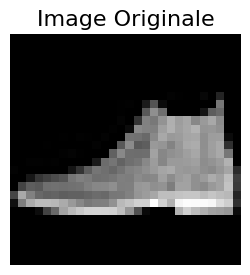

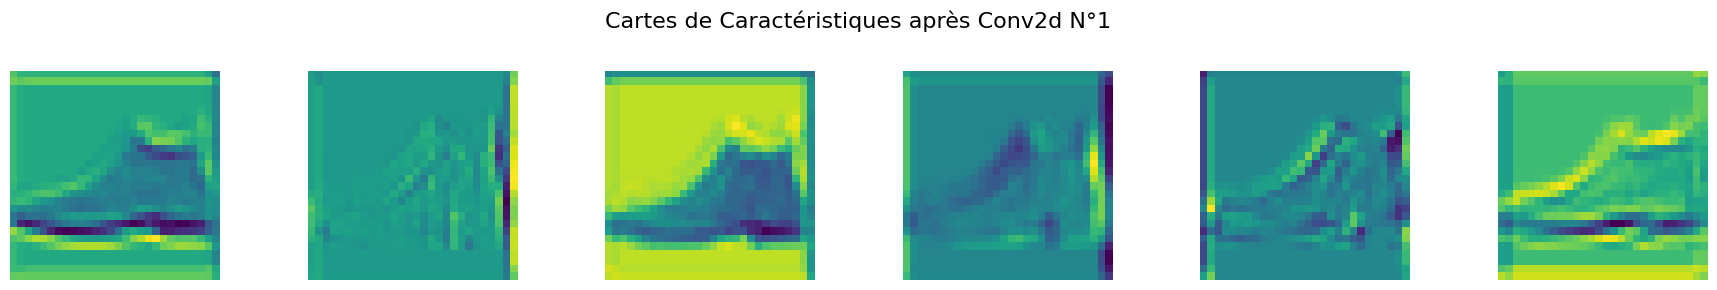

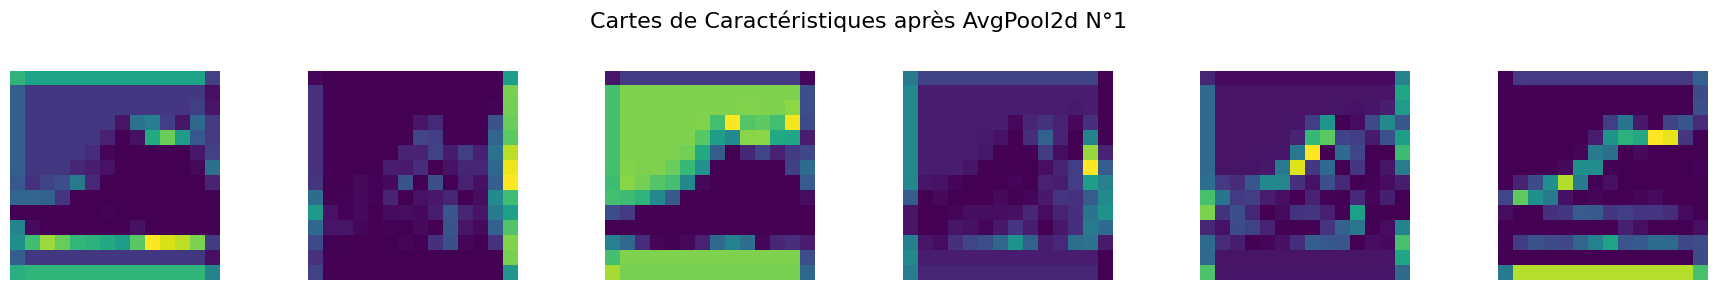

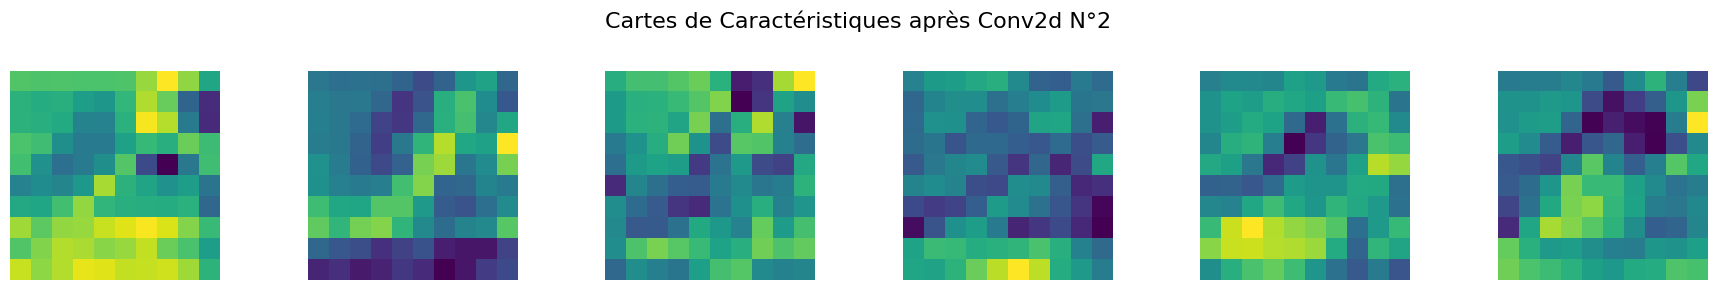

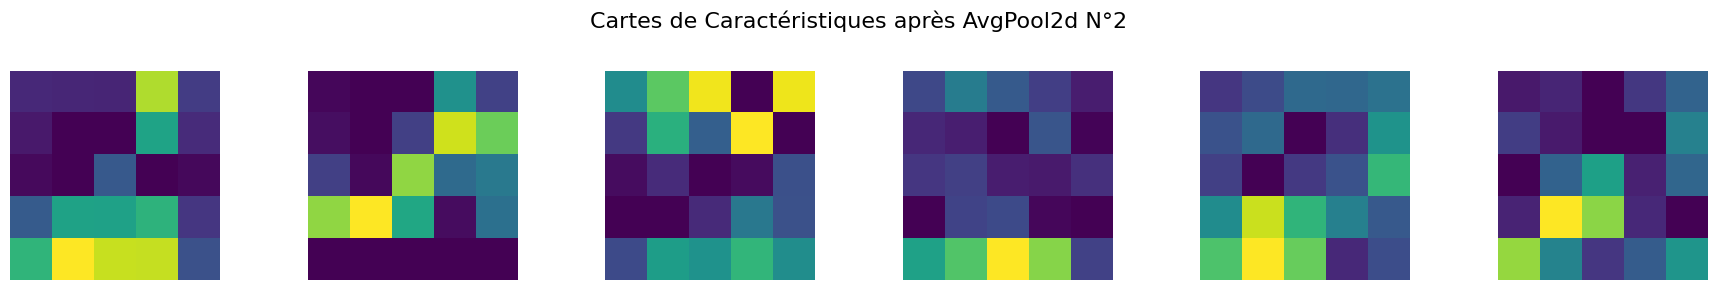

In [23]:
model_cnn.eval()
imgs, _ = next(iter(test_loader))
# Using the first image from the test_loader
img = imgs[0:1].to(device)

with torch.no_grad():
    # Original Image
    plt.figure(figsize=(3, 3))
    plt.imshow(img.cpu().squeeze().numpy() * 0.5 + 0.5, cmap='gray')
    plt.title('Image Originale', fontsize=16)
    plt.axis('off')
    plt.show()

    # After 1st Conv2d layer
    conv1_output = model_cnn.conv_block[0](img)
    plot_maps(conv1_output, "Cartes de Caractéristiques après Conv2d N°1")

    # After 1st AvgPool2d layer
    pool1_output = model_cnn.conv_block[3](model_cnn.conv_block[0:3](img))
    plot_maps(pool1_output, "Cartes de Caractéristiques après AvgPool2d N°1")

    # After 2nd Conv2d layer
    conv2_output = model_cnn.conv_block[4](model_cnn.conv_block[0:4](img))
    plot_maps(conv2_output, "Cartes de Caractéristiques après Conv2d N°2")

    # After 2nd AvgPool2d layer (final feature maps before Flatten)
    pool2_output = model_cnn.conv_block[7](model_cnn.conv_block[0:7](img))
    plot_maps(pool2_output, "Cartes de Caractéristiques après AvgPool2d N°2")

# SECTION 8: Final Comparison


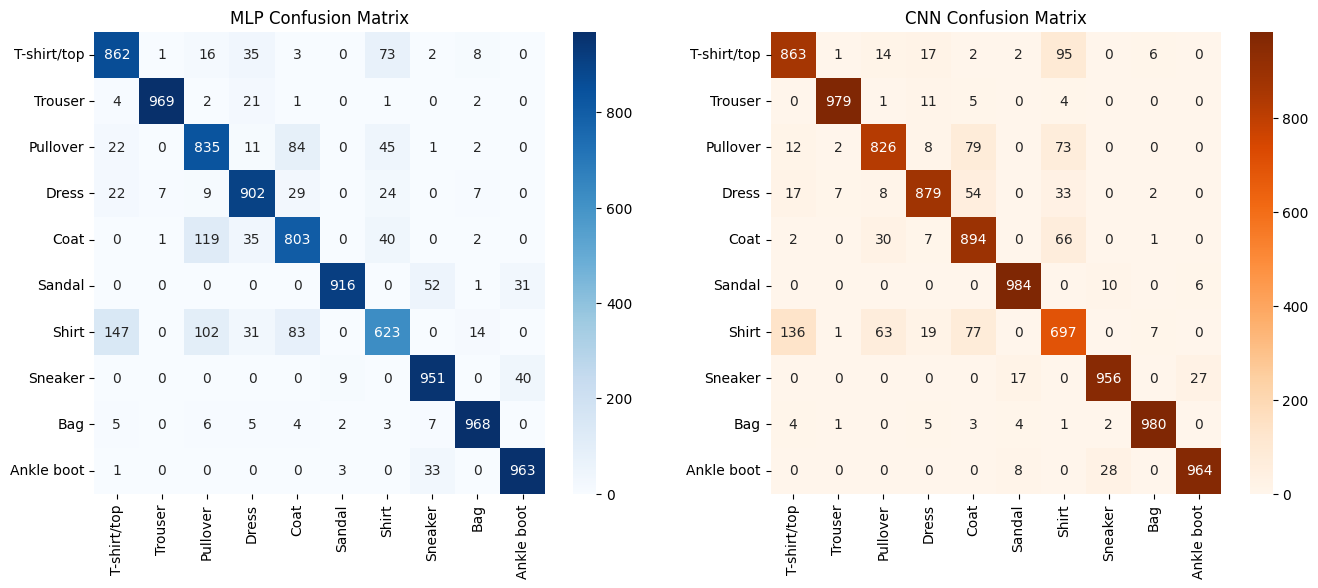

MLP - Acc: 0.8792, F1: 0.8780, Params: 535,818
CNN - Acc: 0.9022, F1: 0.9022, Params: 61,750


In [10]:
acc_mlp, f1_mlp, preds_mlp, labels_mlp = evaluate_model(mlp, test_loader)
acc_cnn, f1_cnn, preds_cnn, labels_cnn = evaluate_model(model_cnn, test_loader)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(labels_mlp, preds_mlp), annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=class_names, yticklabels=class_names)
axes[0].set_title("MLP Confusion Matrix")

sns.heatmap(confusion_matrix(labels_cnn, preds_cnn), annot=True, fmt='d', ax=axes[1], cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
axes[1].set_title("CNN Confusion Matrix")
plt.show()

print(f"MLP - Acc: {acc_mlp:.4f}, F1: {f1_mlp:.4f}, Params: {sum(p.numel() for p in mlp.parameters()):,}")
print(f"CNN - Acc: {acc_cnn:.4f}, F1: {f1_cnn:.4f}, Params: {sum(p.numel() for p in model_cnn.parameters()):,}")

## Courbes d'Apprentissage Comparées (MLP vs CNN)

Ces graphiques montrent l'évolution de la perte d'entraînement, de la perte de validation et de la précision de validation pour les modèles MLP et CNN au fil des époques. Cela permet de visualiser leur comportement pendant l'apprentissage et d'identifier d'éventuels surapprentissage ou sous-apprentissage.

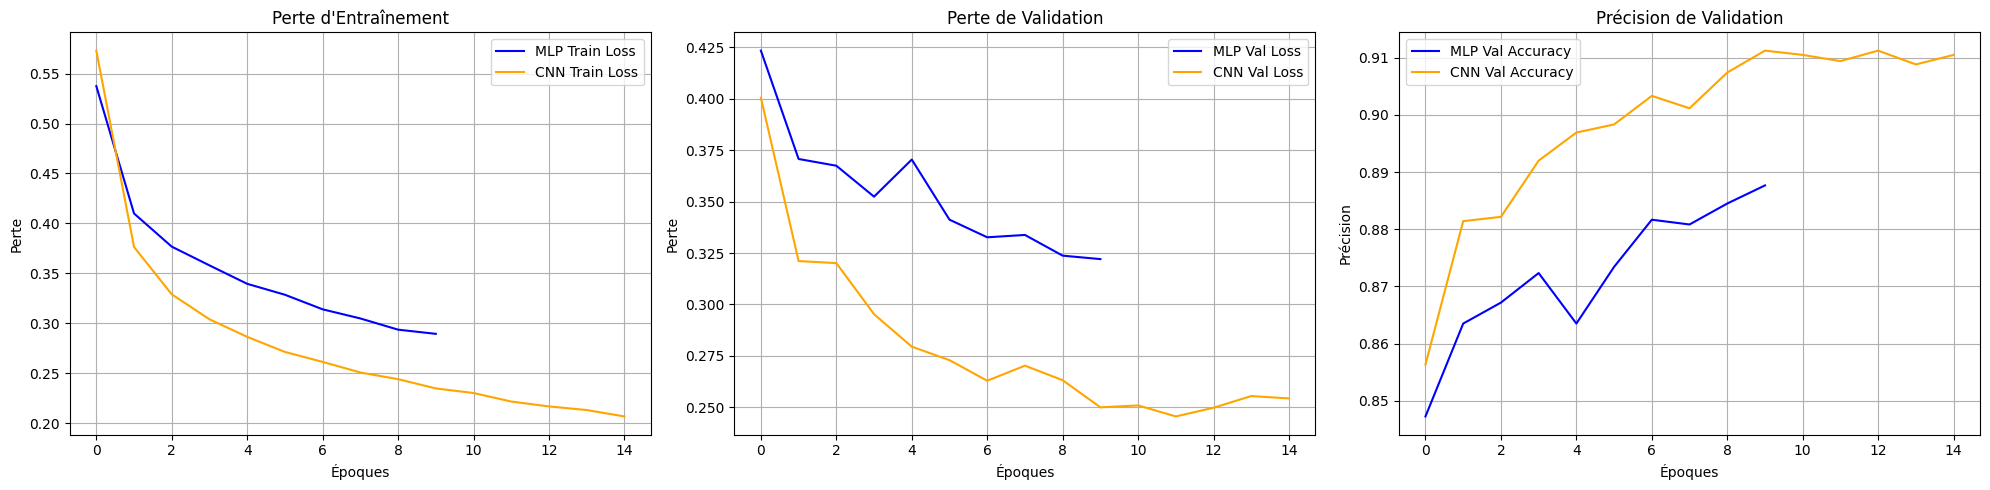

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot Training Loss
axes[0].plot(mlp_history['train_loss'], label='MLP Train Loss', color='blue')
axes[0].plot(cnn_history['train_loss'], label='CNN Train Loss', color='orange')
axes[0].set_title('Perte d\'Entraînement')
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('Perte')
axes[0].legend()
axes[0].grid(True)

# Plot Validation Loss
axes[1].plot(mlp_history['val_loss'], label='MLP Val Loss', color='blue')
axes[1].plot(cnn_history['val_loss'], label='CNN Val Loss', color='orange')
axes[1].set_title('Perte de Validation')
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('Perte')
axes[1].legend()
axes[1].grid(True)

# Plot Validation Accuracy
axes[2].plot(mlp_history['val_acc'], label='MLP Val Accuracy', color='blue')
axes[2].plot(cnn_history['val_acc'], label='CNN Val Accuracy', color='orange')
axes[2].set_title('Précision de Validation')
axes[2].set_xlabel('Époques')
axes[2].set_ylabel('Précision')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## SECTION 10 — Synthesis Analysis: MLP vs CNN for Image Classification

### Why a CNN is more relevant than an MLP

The superiority of the Convolutional Neural Network (CNN) over the Multi-Layer Perceptron (MLP) for image tasks is clearly demonstrated by our results. In **Section 5 and 9**, we observed that our MLP model required **535,818 parameters**, while the LeNet-inspired CNN required only **61,750 parameters**. Despite having nearly **9 times fewer parameters**, the CNN achieved a higher test accuracy (**~90.5%** vs **~87.9%**).

This efficiency stems from **Locality** and **Weight Sharing**. An MLP treats an image as a flat vector, meaning a neuron connected to a pixel in the top-left has no relationship with a neuron connected to its immediate neighbor. In contrast, the CNN's filters (as seen in **Section 8**) act as local feature detectors. Our visualization shows that the first layer filters learn to identify edges and textures. Because these filters slide across the entire image, the model can detect a 'sleeve' or 'sole' regardless of its exact pixel location, whereas an MLP would need to learn that feature separately for every possible position.

### Impact of Architectural Choices

Based on our experiments in **Section 7**, we can quantify how specific design choices influence performance:

1.  **Pooling (MaxPool vs AvgPool):** In **Exp4**, replacing Average Pooling with Max Pooling resulted in the highest accuracy (**~90.6%**). Max pooling is generally more effective because it preserves the strongest activations (the most prominent features) while providing translation invariance.
2.  **Padding:** **Exp2** (no padding) showed that while the model still performs well, padding is crucial for preserving spatial information at the borders. Without it, the feature maps shrink too rapidly, potentially losing detail in deep architectures.
3.  **Stride:** **Exp3** demonstrated that using a stride of 2 is a valid learnable alternative to pooling for downsampling. It maintains high performance while reducing the computational footprint early in the network.
4.  **Filter Depth:** **Exp5** showed that doubling the number of filters increases capacity. However, the performance gain was marginal compared to the baseline, suggesting that for a simple dataset like Fashion-MNIST, the 'width' of the network is less critical than its structural ability to extract spatial features.
5.  **1x1 Convolutions:** **Exp6** introduced a 1x1 convolution, which allows for channel-wise feature mixing. This is a cheap way to increase non-linearity and refine feature maps without affecting spatial dimensions.

### Limits and Conclusion

While CNNs are robust, they are not perfect. The confusion matrices in **Section 9** show that even the CNN struggles to distinguish between visually similar classes like **Shirts**, **Coats**, and **Pullovers**. CNNs also require significant data to learn these spatial hierarchies and can be sensitive to adversarial attacks or extreme rotations/distortions that they haven't seen during training. Nevertheless, for standard image classification, the inductive bias of CNNs makes them far more relevant and efficient than MLPs.

## Architecture du Modèle CNN (LeNet-5 Adapté)

L'architecture CNN utilisée dans ce projet est une adaptation du modèle classique LeNet-5, conçue pour la classification d'images. Elle se compose de deux blocs principaux : un bloc convolutif pour l'extraction des caractéristiques et un bloc de couches entièrement connectées pour la classification.

**Vue d'ensemble :**

1.  **Couche Convolutive 1 (`nn.Conv2d`) :**
    *   Prend en entrée une image en niveaux de gris de 28x28 pixels (1 canal).
    *   Applique 6 filtres (kernels) de taille 5x5.
    *   Utilise un padding de 2 pour maintenir la taille spatiale de 28x28 après la convolution.
    *   Passe par une normalisation de batch (`nn.BatchNorm2d`) et une fonction d'activation ReLU.

2.  **Couche de Pooling 1 (`nn.AvgPool2d`) :**
    *   Effectue un pooling moyen sur des fenêtres 2x2 avec un stride de 2.
    *   Réduit la taille spatiale de la carte de caractéristiques de 28x28 à 14x14.

3.  **Couche Convolutive 2 (`nn.Conv2d`) :**
    *   Prend en entrée les 6 cartes de caractéristiques de 14x14.
    *   Applique 16 filtres de taille 5x5.
    *   Ne spécifie pas de padding, ce qui réduit la taille spatiale de 14x14 à 10x10.
    *   Passe par une normalisation de batch (`nn.BatchNorm2d`) et une fonction d'activation ReLU.

4.  **Couche de Pooling 2 (`nn.AvgPool2d`) :**
    *   Effectue un pooling moyen sur des fenêtres 2x2 avec un stride de 2.
    *   Réduit la taille spatiale de la carte de caractéristiques de 10x10 à 5x5.

5.  **Couche de Flatten (`nn.Flatten`) :**
    *   Aplatit les 16 cartes de caractéristiques de 5x5 en un vecteur unidimensionnel de 16 * 5 * 5 = 400 éléments.

6.  **Couche Entièrement Connectée 1 (`nn.Linear`) :**
    *   Prend les 400 éléments en entrée.
    *   Produit 120 sorties.
    *   Applique une fonction d'activation ReLU et un `Dropout` de 0.3 pour la régularisation.

7.  **Couche Entièrement Connectée 2 (`nn.Linear`) :**
    *   Prend les 120 éléments en entrée.
    *   Produit 84 sorties.
    *   Applique une fonction d'activation ReLU.

8.  **Couche de Sortie (`nn.Linear`) :**
    *   Prend les 84 éléments en entrée.
    *   Produit 10 sorties, correspondant aux 10 classes de Fashion-MNIST.

Cette architecture est conçue pour progressivement extraire des caractéristiques de plus haut niveau des images tout en réduisant leur dimensionnalité spatiale, aboutissant à une classification finale.

In [14]:
print(model_cnn)

LeNet(
  (conv_block): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (fc_block): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=120, out_features=84, bias=True)
    (5): ReLU()
    (6): Linear(in_features=84, out_features=10, bias=True)
  )
)


## Résumé Détaillé du Modèle CNN (LeNet-5) avec `torchsummary`

Pour une vue structurée de l'architecture du modèle, y compris les formes de sortie de chaque couche et le nombre de paramètres, nous pouvons utiliser la bibliothèque `torchsummary`. Cela fournit un aperçu plus détaillé que le simple `print(model_cnn)`.

In [17]:
# Installer torchsummary si ce n'est pas déjà fait
!pip install torchsummary

In [18]:
from torchsummary import summary

# Assurez-vous que le modèle est sur le bon appareil et qu'il est défini
# model_cnn est défini dans la cellule 93af487b
# Mettez le modèle en mode évaluation si vous voulez un résumé statique sans impact sur les caluls de gradients
model_cnn.eval()

# Afficher le résumé du modèle
# L'entrée est de (canaux, hauteur, largeur) pour une image de Fashion-MNIST
summary(model_cnn, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             156
       BatchNorm2d-2            [-1, 6, 28, 28]              12
              ReLU-3            [-1, 6, 28, 28]               0
         AvgPool2d-4            [-1, 6, 14, 14]               0
            Conv2d-5           [-1, 16, 10, 10]           2,416
       BatchNorm2d-6           [-1, 16, 10, 10]              32
              ReLU-7           [-1, 16, 10, 10]               0
         AvgPool2d-8             [-1, 16, 5, 5]               0
           Flatten-9                  [-1, 400]               0
           Linear-10                  [-1, 120]          48,120
             ReLU-11                  [-1, 120]               0
          Dropout-12                  [-1, 120]               0
           Linear-13                   [-1, 84]          10,164
             ReLU-14                   